In [1]:
from misc import *
import constant

In [2]:
# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]

In [3]:
def add_upsilon(ax, xS, **kwargs):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass, color="k", linewidth=1.5, label=label, ls="--", **kwargs)

In [4]:
log_pt_squared = np.log(df["J_psi_1S_PT"]**2)

Histogram not saved to file


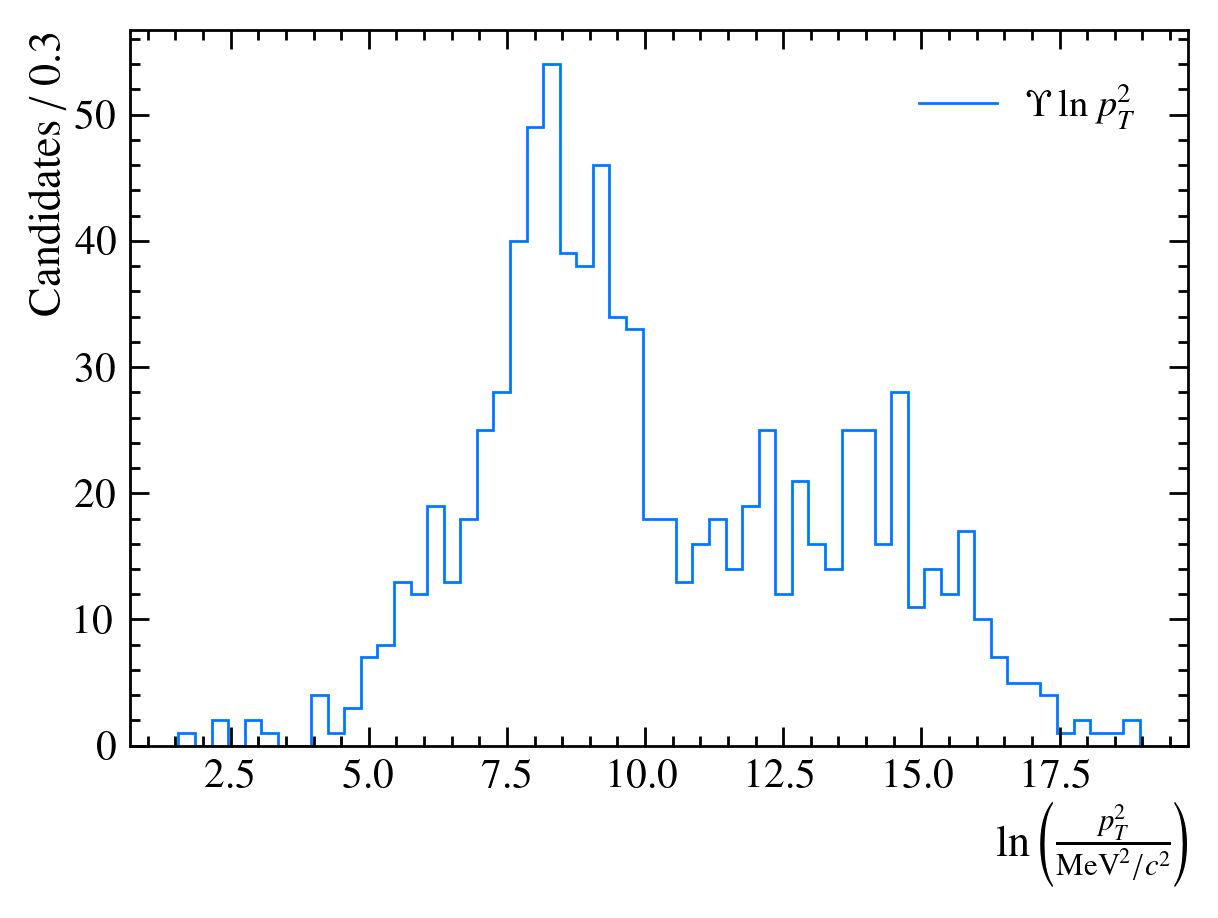

In [5]:
fig, ax = histogram_fig(
    [
        HistogramPlot(log_pt_squared, r"$\Upsilon \ln{p_T^2}$", bins=0.3)
    ],
    False,
    xlabel=r"$\ln\left(\frac{p_T^2}{\mathrm{MeV}^2/c^2}\right)$"
)

Histogram not saved to file


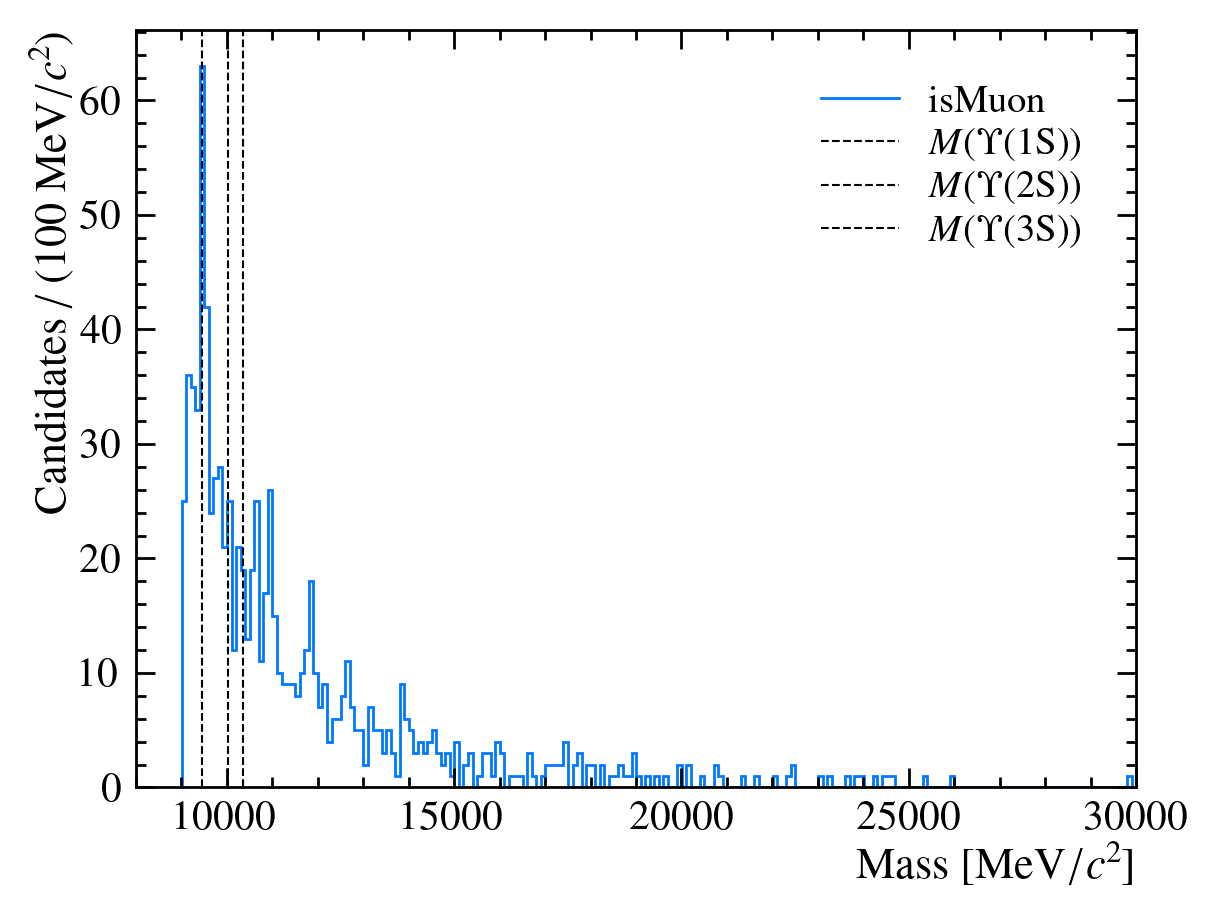

In [6]:
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "isMuon", bins=100)],
    False,
    xlim=[8000, 30_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
add_upsilon(ax, range(1, 4))
ax.legend()

Histogram not saved to file


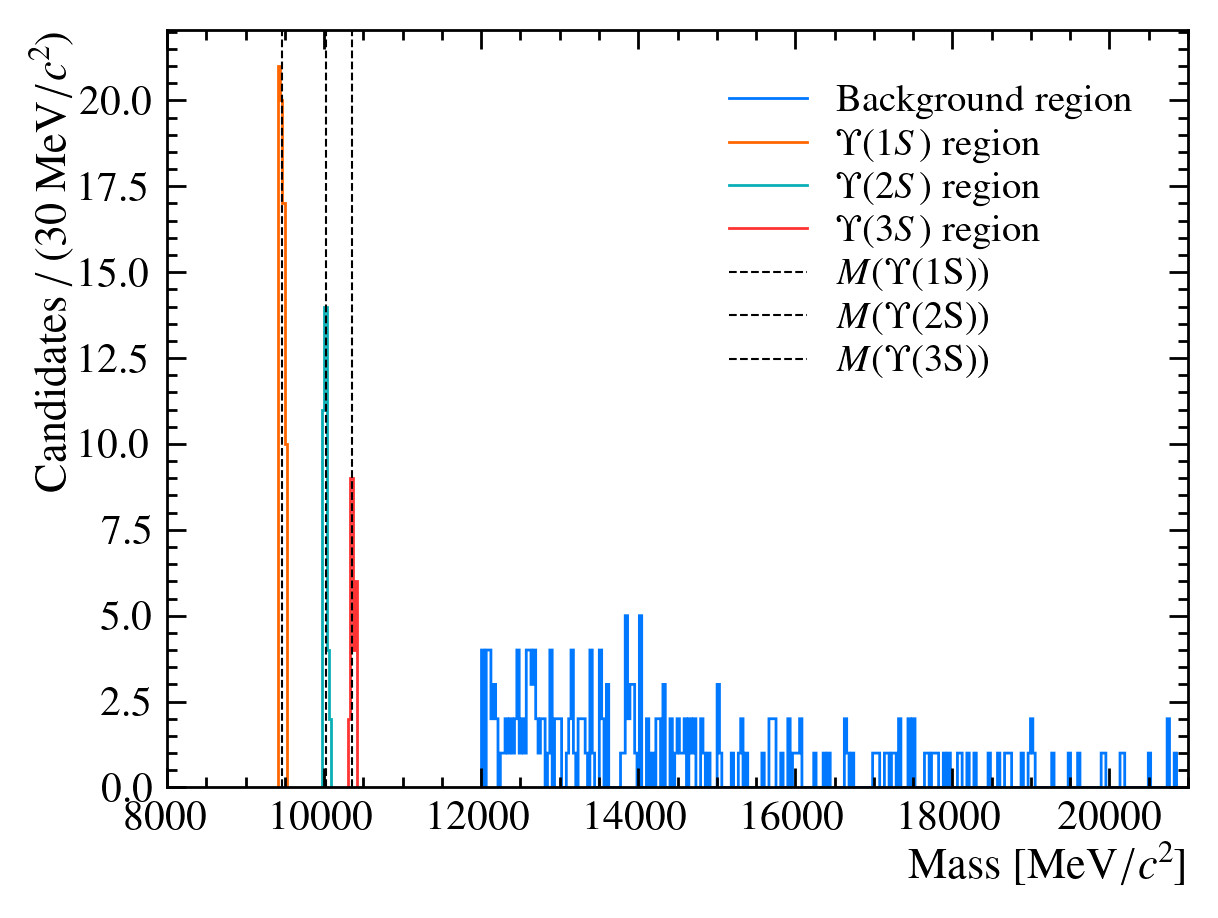

In [7]:
half_mass_range = 53 # 1 std
upsilon_1S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_1S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_1S_MASS + half_mass_range)]
upsilon_2S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_2S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_2S_MASS + half_mass_range)]
upsilon_3S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_3S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_3S_MASS + half_mass_range)]
background_df = df[(df["J_psi_1S_M"] > 12_000)]

fig, ax = histogram_fig(
    [   HistogramPlot(background_df["J_psi_1S_M"], "Background region", bins=30),
        HistogramPlot(upsilon_1S_df["J_psi_1S_M"], r"$\Upsilon(1S)$ region", bins=30),
        HistogramPlot(upsilon_2S_df["J_psi_1S_M"], r"$\Upsilon(2S)$ region", bins=30),
        HistogramPlot(upsilon_3S_df["J_psi_1S_M"], r"$\Upsilon(3S)$ region", bins=30),
     ],
    False,
    xlim=[8000, 21_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
add_upsilon(ax, range(1, 4))
ax.legend()

# $\ln p_T^2$ for $\Upsilon$

Histogram not saved to file
Histogram not saved to file


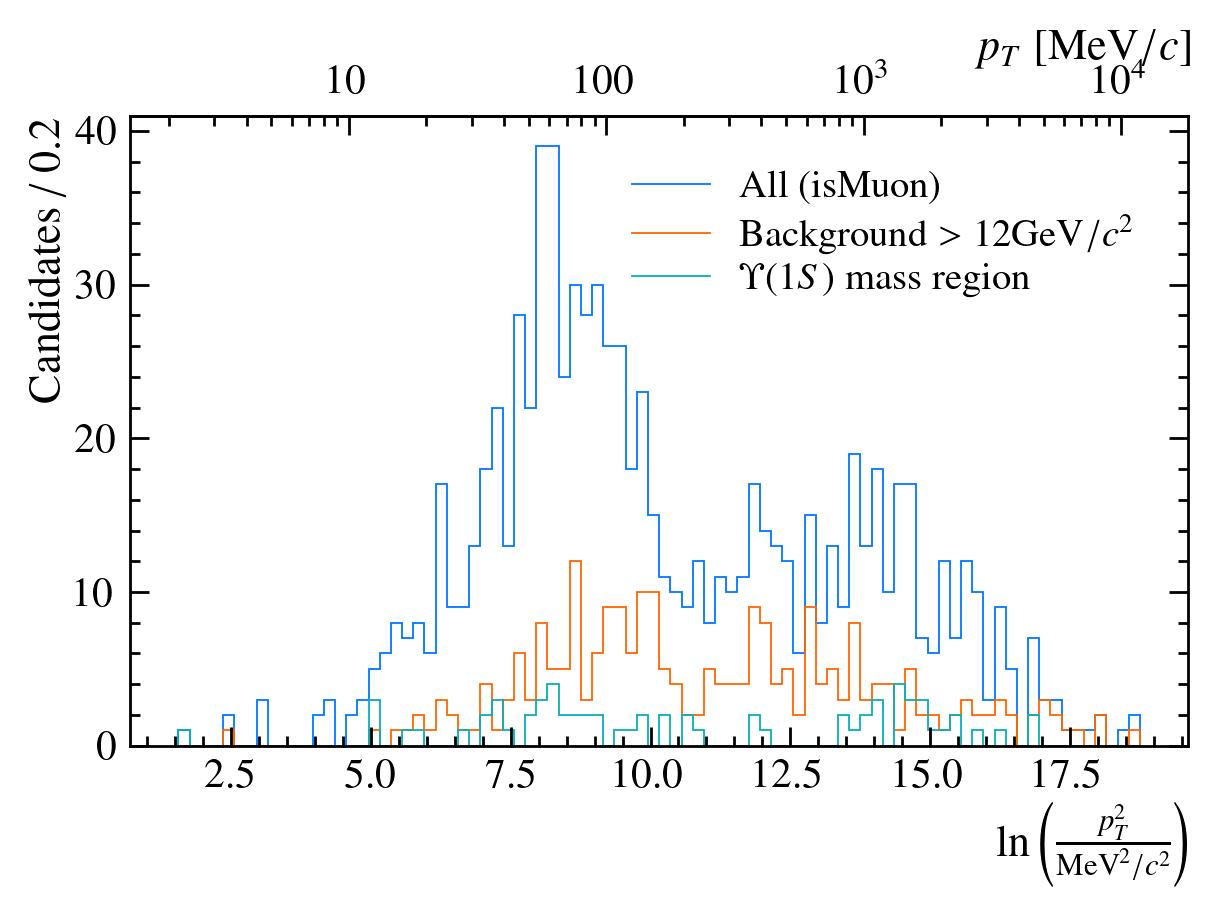

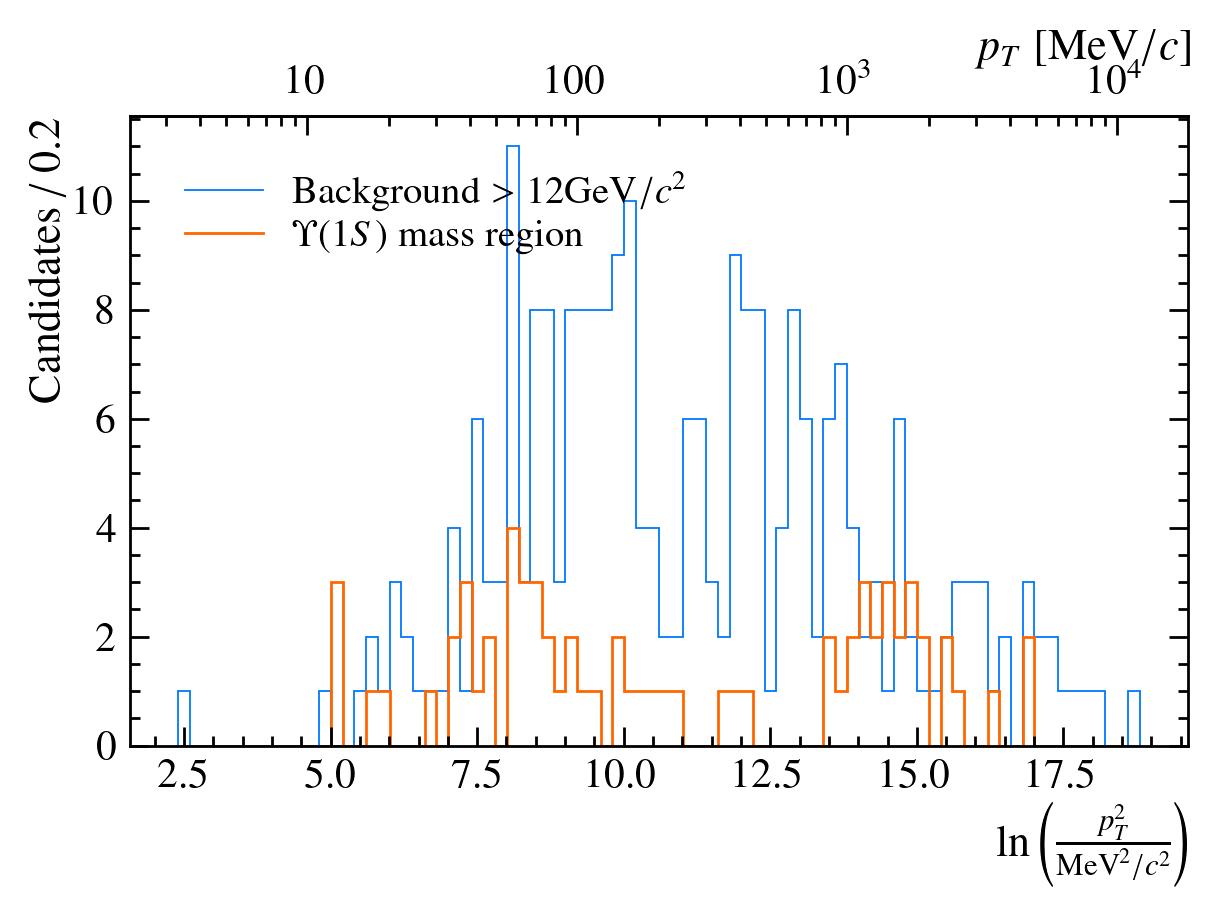

In [8]:
upsilon_1S_log_pt_squared = np.log((upsilon_1S_df["J_psi_1S_PT"])**2)
upsilon_2S_log_pt_squared = np.log((upsilon_2S_df["J_psi_1S_PT"])**2)
upsilon_3S_log_pt_squared = np.log((upsilon_3S_df["J_psi_1S_PT"])**2)

background_log_pt_squared = np.log((background_df["J_psi_1S_PT"])**2)
all_log_pt_squared = np.log((df["J_psi_1S_PT"])**2)

# fig, ax = histogram_fig(
#     [
#         first := HistogramPlot(background_df["J_psi_1S_PT"], r"Background", bins=10, linewidth=1.3, alpha=0.5),
#         HistogramPlot(upsilon_1S_df["J_psi_1S_PT"], r"$\Upsilon(1S)$", bins=first.bin_edges, linewidth=1.3),
#         HistogramPlot(upsilon_2S_df["J_psi_1S_PT"], r"$\Upsilon(2S)$", bins=first.bin_edges, linewidth=1.3),
#         HistogramPlot(upsilon_3S_df["J_psi_1S_PT"], r"$\Upsilon(3S)$", bins=first.bin_edges, linewidth=1.3),
#     ],
#     False,
#     xlabel=r"$p_T$",
#     unit_tex=r"\mathrm{MeV}/c",
#     # xlim=[0, 400]
# )

fig, ax = histogram_fig(
    [
        first := HistogramPlot(all_log_pt_squared, "All (isMuon)", bins=0.2, linewidth=1.3),
        HistogramPlot(background_log_pt_squared, r"Background $>12 \mathrm{GeV}/c^2$", bins=first.bin_edges, linewidth=1.3),
        HistogramPlot(upsilon_1S_log_pt_squared, r"$\Upsilon(1S)$ mass region", bins=first.bin_edges, linewidth=1.3),
    ],
    False,
    xlabel=r"$\ln\left(\frac{p_T^2}{\mathrm{MeV}^2/c^2}\right)$"
)

add_log_pt_axis(ax)

fig, ax = histogram_fig(
    [
        first := HistogramPlot(background_log_pt_squared, r"Background $>12 \mathrm{GeV}/c^2$", bins=0.2, linewidth=1.3),
        HistogramPlot(upsilon_1S_log_pt_squared, r"$\Upsilon(1S)$ mass region", bins=first.bin_edges),
        # HistogramPlot(all_log_pt_squared, "All (isMuon)", bins=first.bin_edges, linewidth=1.3),
    ],
    False,
    xlabel=r"$\ln\left(\frac{p_T^2}{\mathrm{MeV}^2/c^2}\right)$"
)

add_log_pt_axis(ax)

# Muon $p_T^2$

Histogram not saved to file
Histogram not saved to file


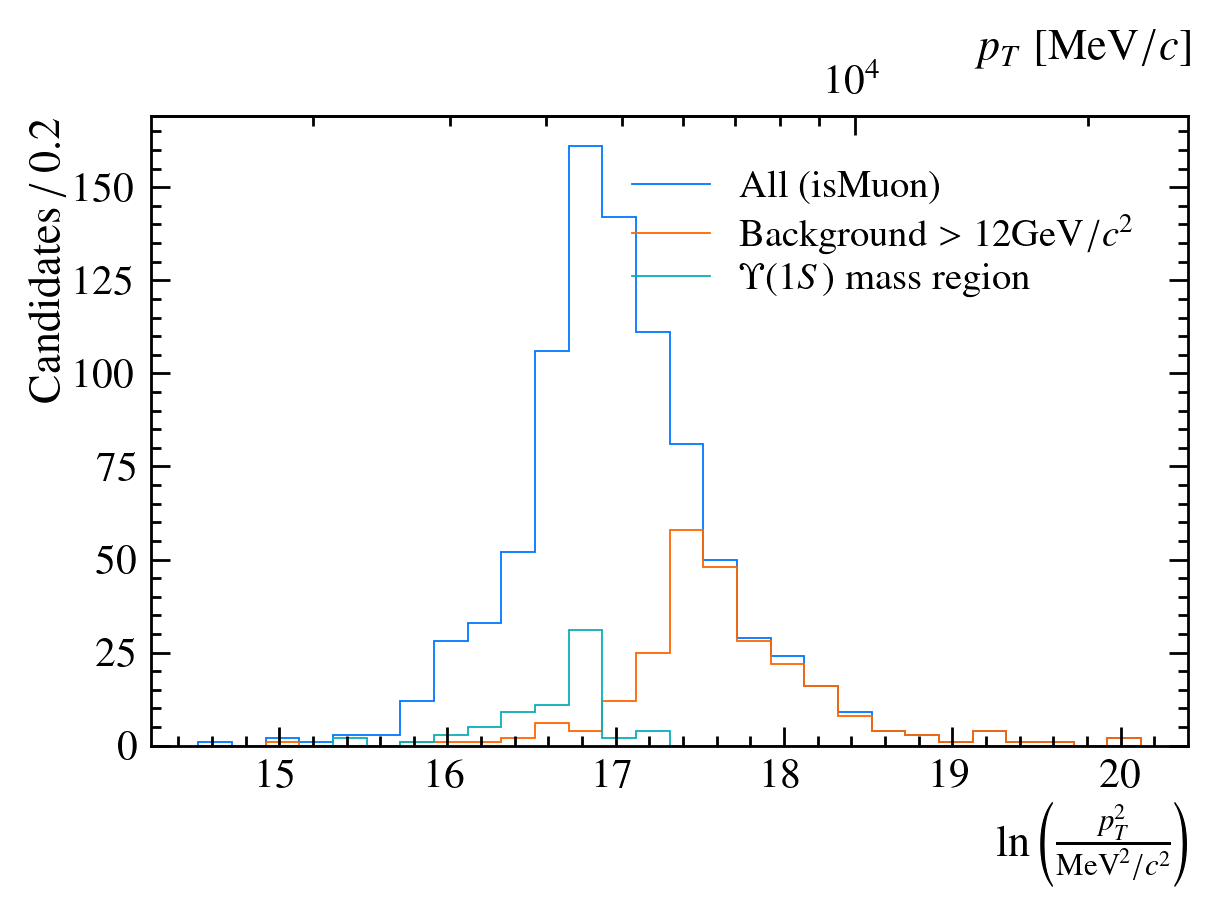

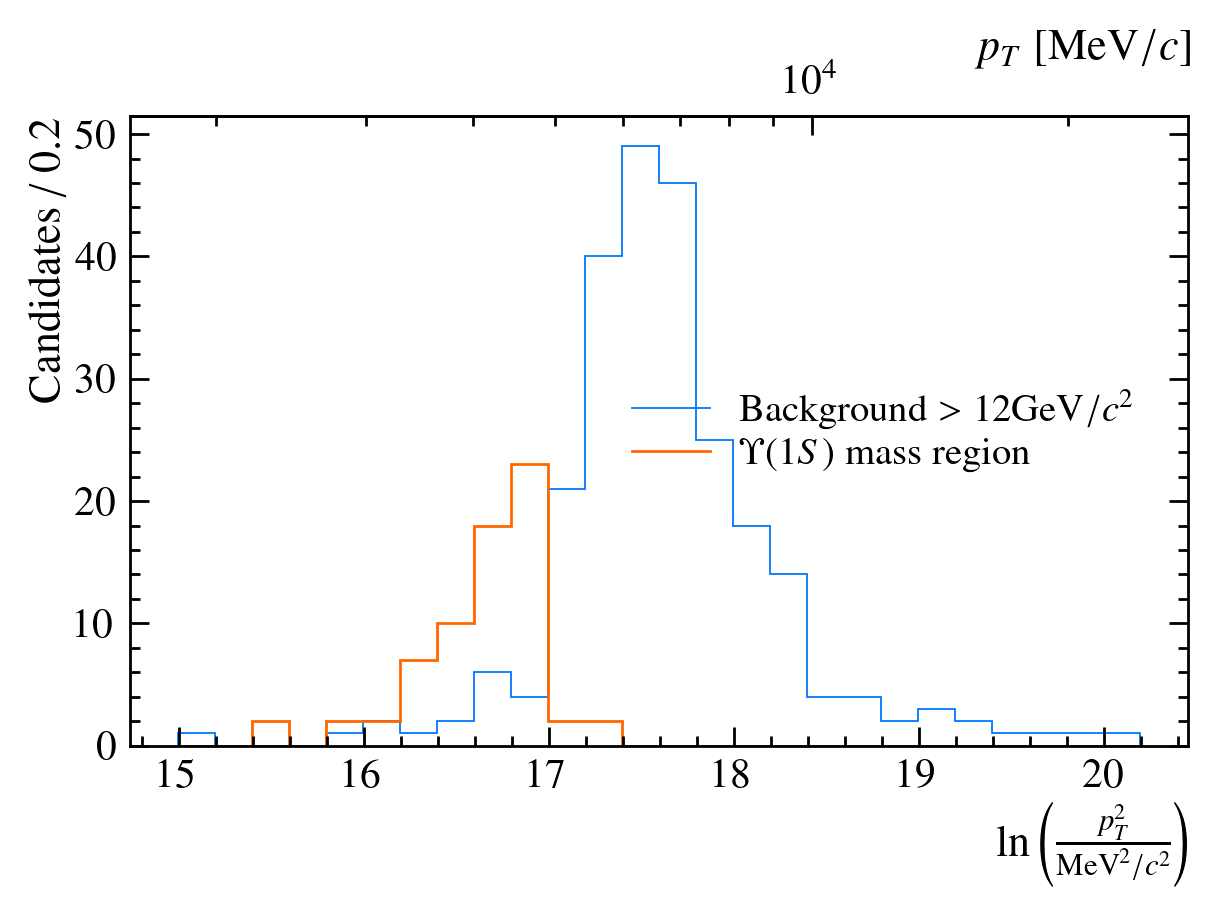

In [9]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(log_pT2(df["muplus_PT"]), "All (isMuon)", bins=0.2, linewidth=1.3),
        HistogramPlot(log_pT2(background_df["muplus_PT"]), r"Background $>12 \mathrm{GeV}/c^2$", bins=first.bin_edges, linewidth=1.3),
        HistogramPlot(log_pT2(upsilon_1S_df["muplus_PT"]), r"$\Upsilon(1S)$ mass region", bins=first.bin_edges, linewidth=1.3),
    ],
    False,
    xlabel=r"$\ln\left(\frac{p_T^2}{\mathrm{MeV}^2/c^2}\right)$"
)
add_log_pt_axis(ax)


fig, ax = histogram_fig(
    [
        first := HistogramPlot(log_pT2(background_df["muplus_PT"]), r"Background $>12 \mathrm{GeV}/c^2$", bins=0.2, linewidth=1.3),
        HistogramPlot(log_pT2(upsilon_1S_df["muplus_PT"]), r"$\Upsilon(1S)$ mass region", bins=first.bin_edges),
    ],
    False,
    xlabel=r"$\ln\left(\frac{p_T^2}{\mathrm{MeV}^2/c^2}\right)$"
)
add_log_pt_axis(ax)


# Number of Tracks

Histogram not saved to file


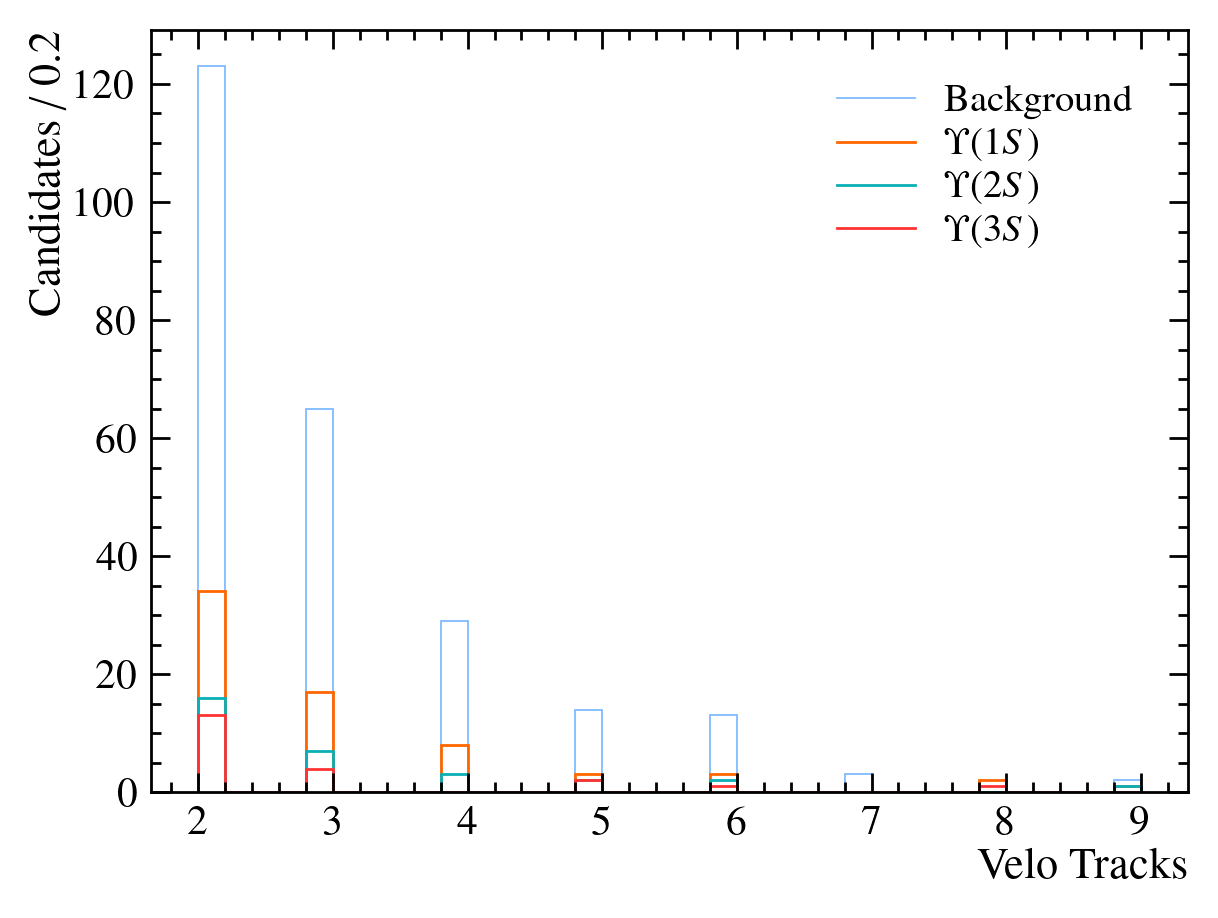

In [10]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(background_df["nVeloTracks"], r"Background", bins=0.2, linewidth=1.3, alpha=0.5),
        HistogramPlot(upsilon_1S_df["nVeloTracks"], r"$\Upsilon(1S)$", bins=first.bin_edges,),
        HistogramPlot(upsilon_2S_df["nVeloTracks"], r"$\Upsilon(2S)$", bins=first.bin_edges,),
        HistogramPlot(upsilon_3S_df["nVeloTracks"], r"$\Upsilon(3S)$", bins=first.bin_edges,),
    ],
    False,
    xlabel=r"Velo Tracks"
)

Histogram not saved to file


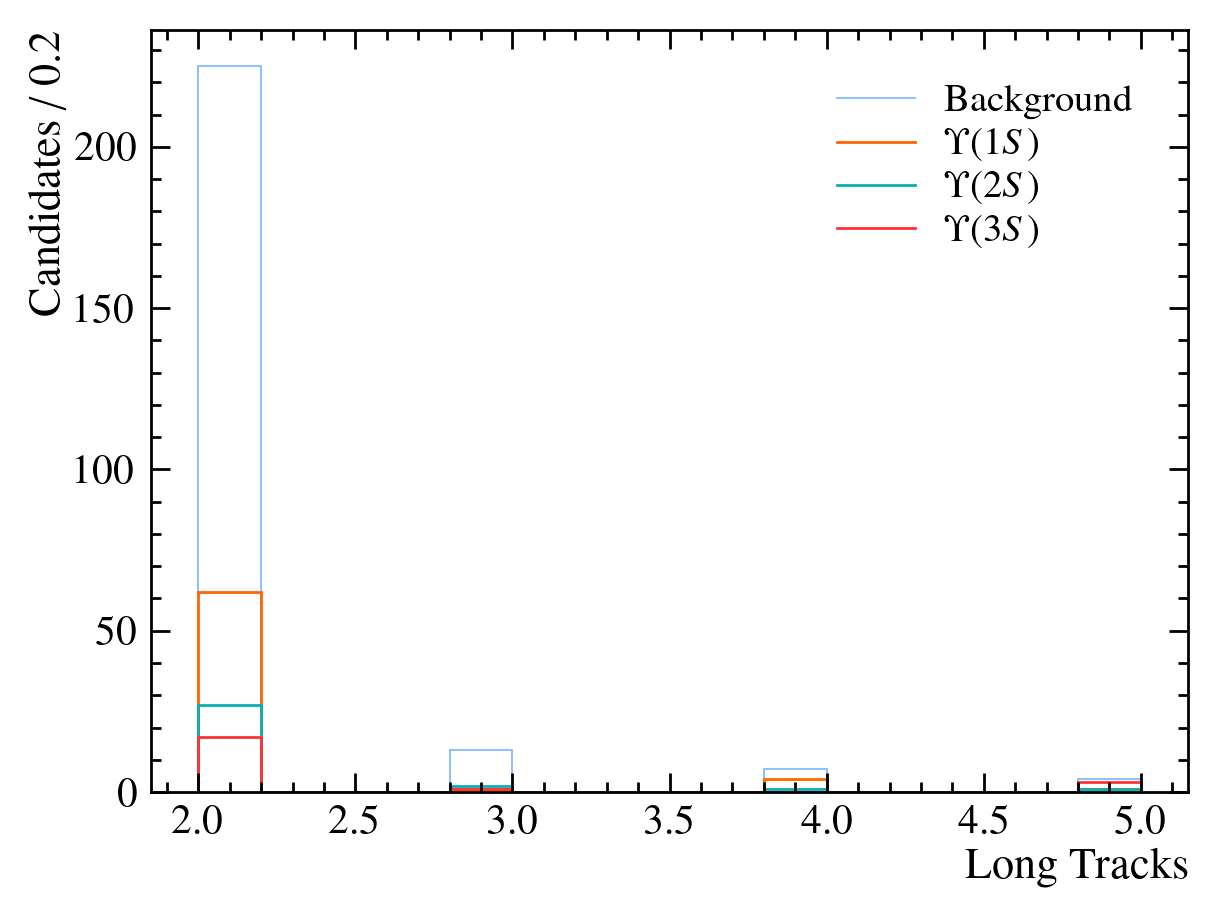

In [11]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(background_df["nLongTracks"], r"Background", bins=0.2, linewidth=1.3, alpha=0.5),
        HistogramPlot(upsilon_1S_df["nLongTracks"], r"$\Upsilon(1S)$", bins=first.bin_edges,),
        HistogramPlot(upsilon_2S_df["nLongTracks"], r"$\Upsilon(2S)$", bins=first.bin_edges,),
        HistogramPlot(upsilon_3S_df["nLongTracks"], r"$\Upsilon(3S)$", bins=first.bin_edges,),
    ],
    False,
    xlabel=r"Long Tracks"
)

# Rapidity

Histogram not saved to file


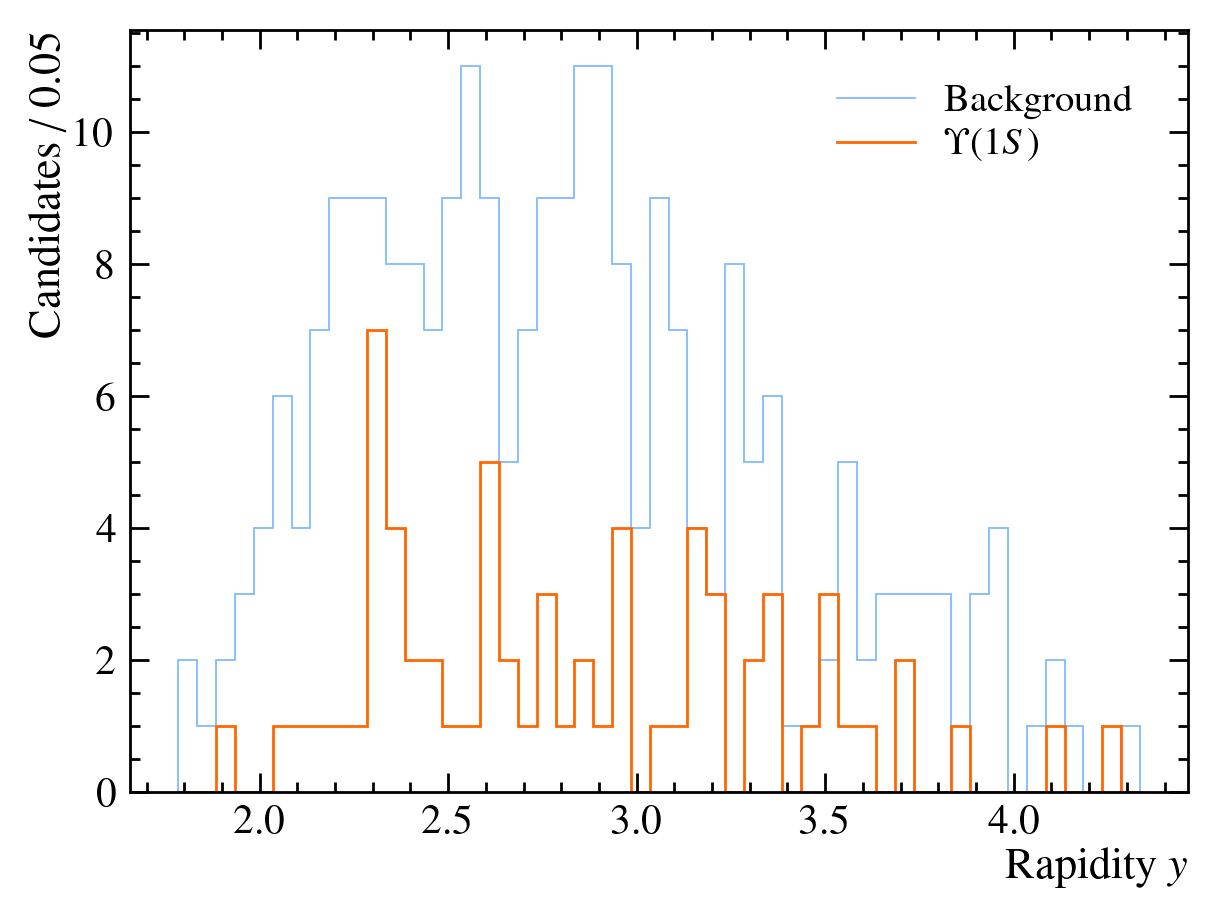

In [12]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(background_df["J_psi_1S_Y"], r"Background", bins=0.05, linewidth=1.3, alpha=0.5),
        HistogramPlot(upsilon_1S_df["J_psi_1S_Y"], r"$\Upsilon(1S)$", bins=first.bin_edges,),
        # HistogramPlot(upsilon_2S_df["J_psi_1S_Y"], r"$\Upsilon(2S)$", bins=first.bin_edges,),
        # HistogramPlot(upsilon_3S_df["J_psi_1S_Y"], r"$\Upsilon(3S)$", bins=first.bin_edges,),
    ],
    False,
    xlabel=r"Rapidity $y$"
)

# $p_T$ cut

Histogram not saved to file


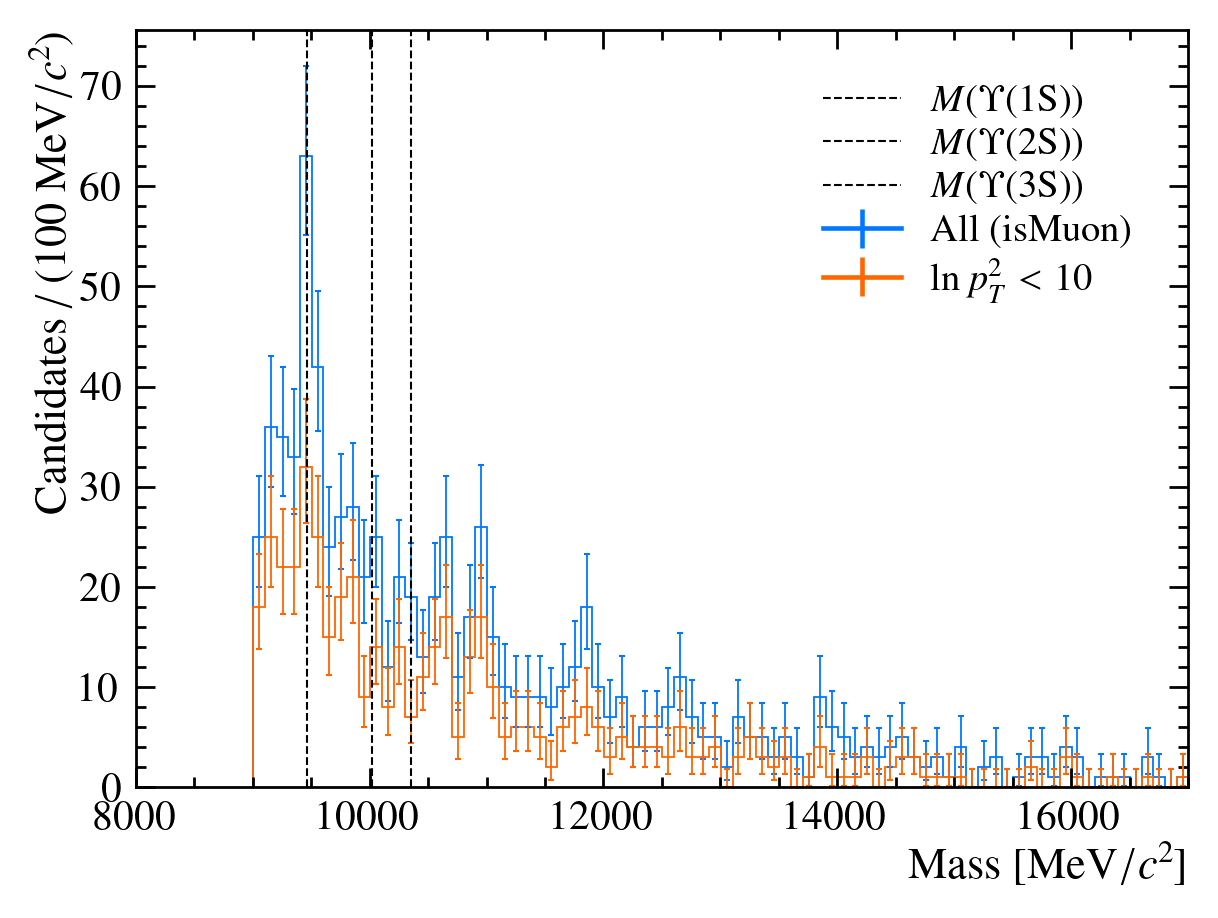

In [13]:
low_ln_pt2 = df[np.log(df["J_psi_1S_PT"]**2) < 10]
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "All (isMuon)", bins=100, linewidth=1.3, error=True),
     HistogramPlot(low_ln_pt2["J_psi_1S_M"], r"$\ln p_T^2 < 10$", bins=100, linewidth=1.3, error=True)],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,4))
ax.legend()

# Muon $p_T$ differences

Histogram not saved to file


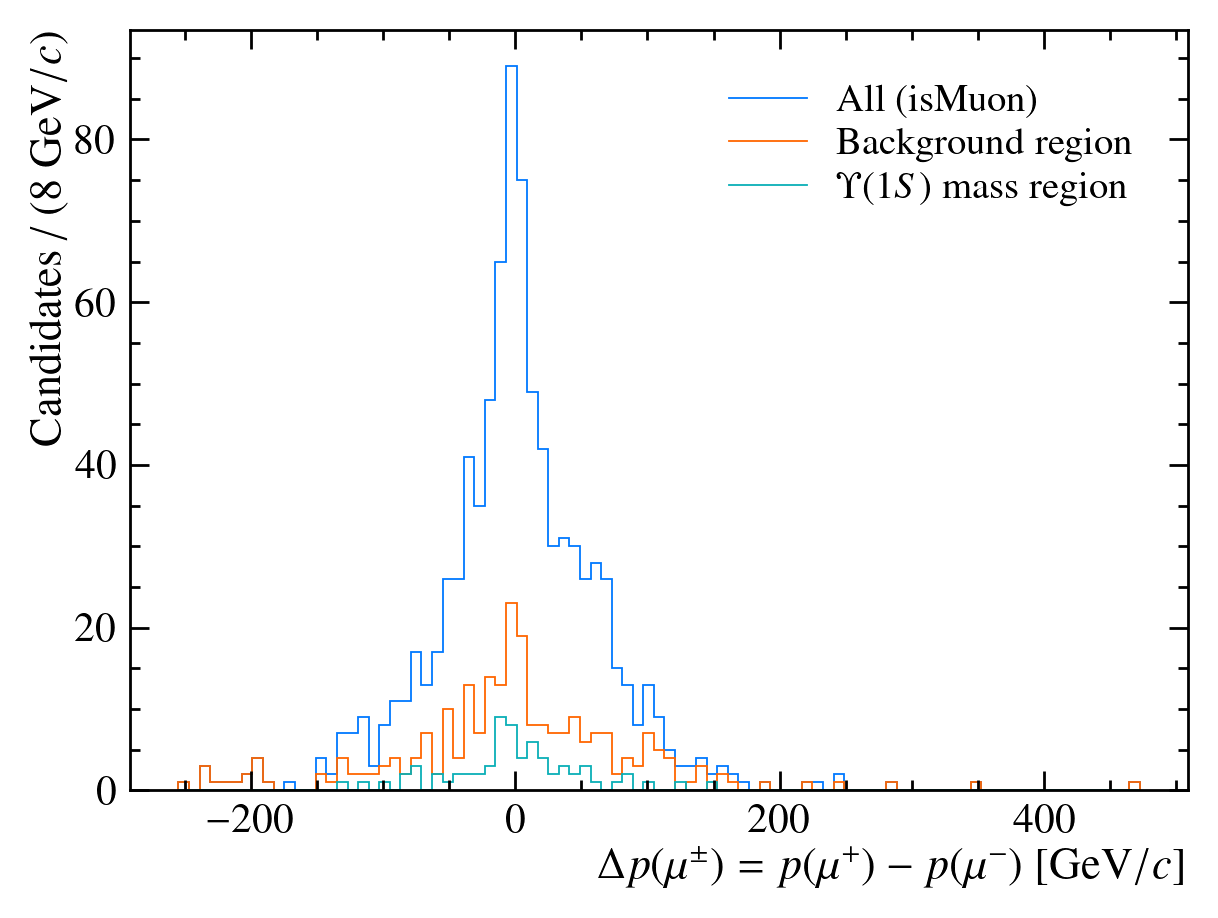

In [14]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(df["muplus_P"]/1000 - df["muminus_P"]/1000, "All (isMuon)", linewidth=1.3, bins=8),
        HistogramPlot(background_df["muplus_P"]/1000 - background_df["muminus_P"]/1000, r"Background region", linewidth=1.3, bins=first.bin_edges),
        HistogramPlot(upsilon_1S_df["muplus_P"]/1000 - upsilon_1S_df["muminus_P"]/1000, r"$\Upsilon(1S)$ mass region", linewidth=1.3, bins=first.bin_edges),

    ],
    False,
    xlabel=r"$\Delta p(\mu^\pm) = p(\mu^+) - p(\mu^-)$",
    unit_tex=r"\mathrm{GeV}/c"
)

Histogram not saved to file
Histogram not saved to file


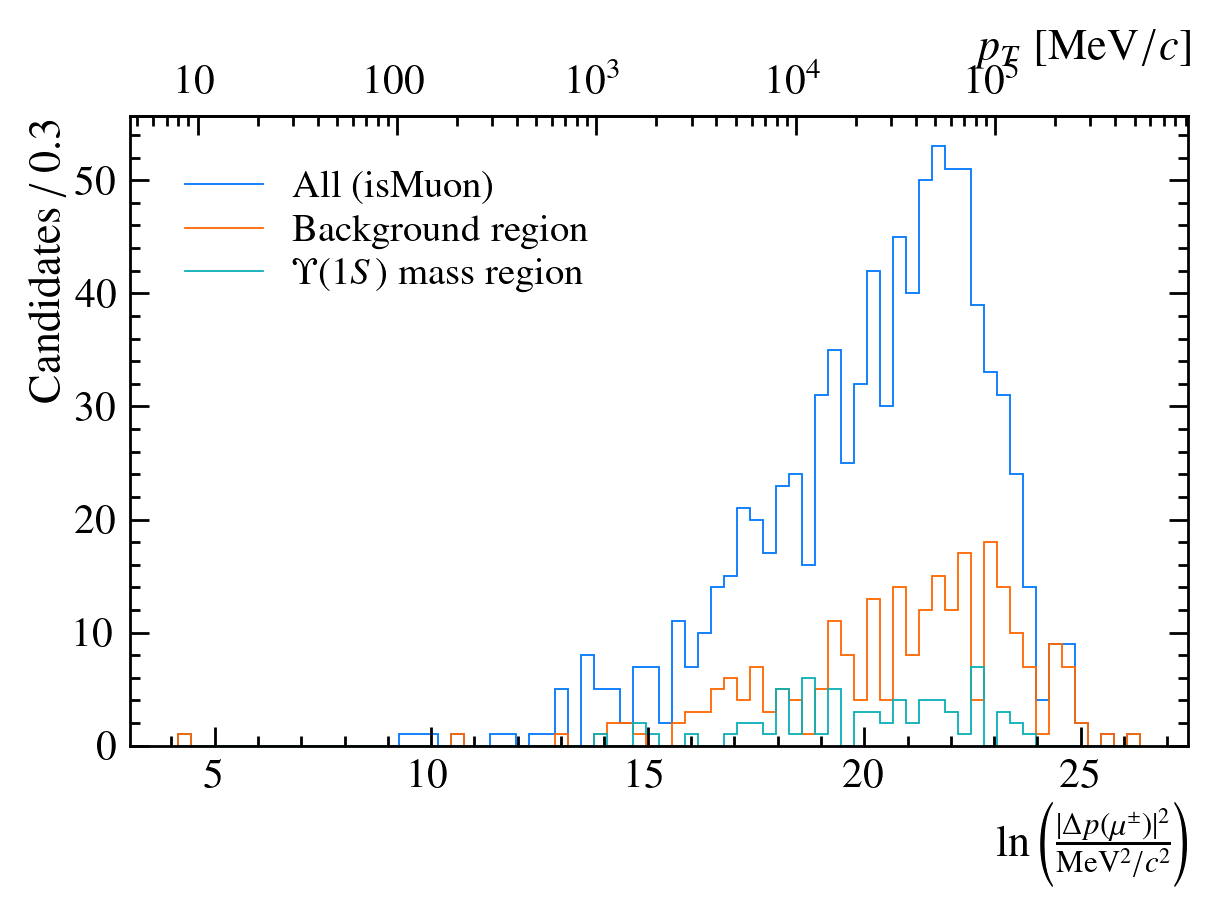

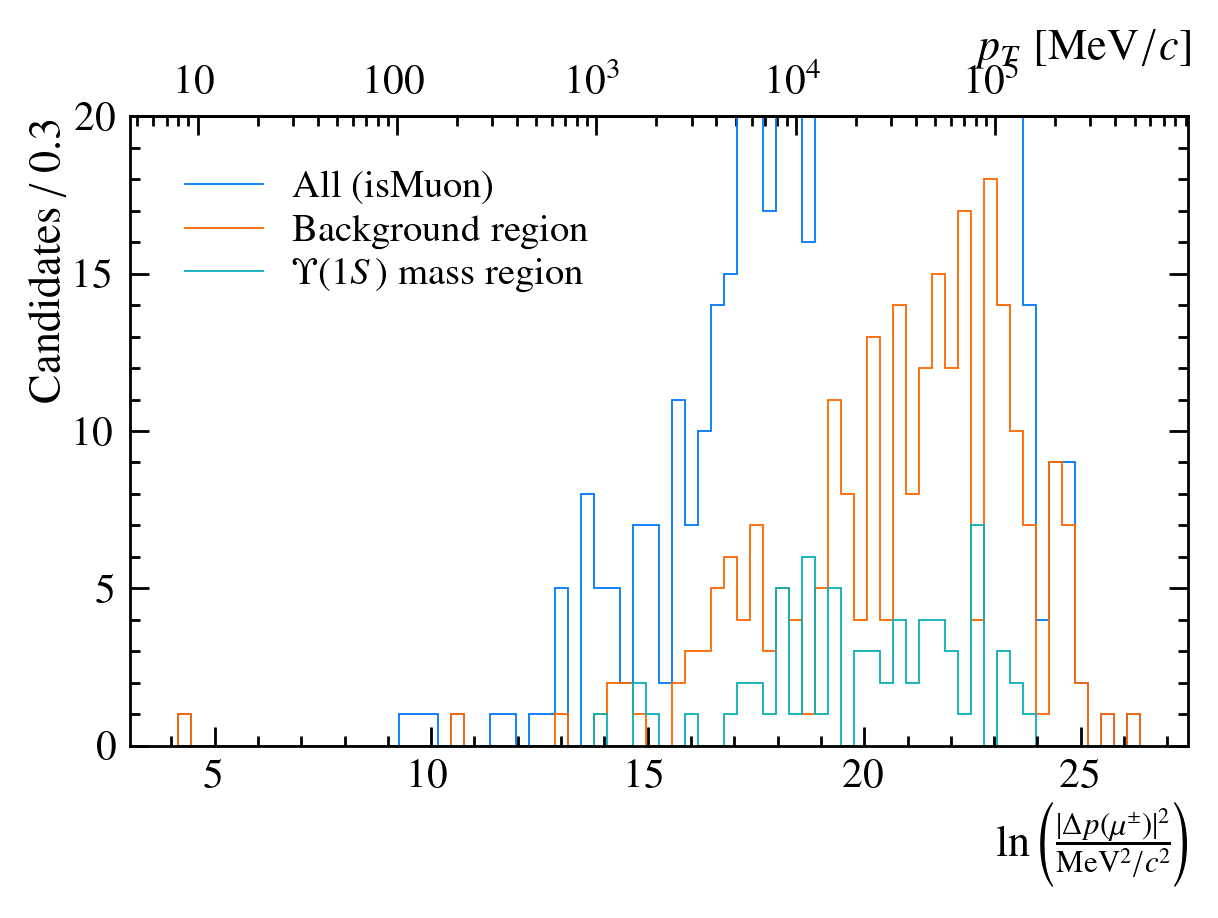

In [15]:
fig, ax = histogram_fig(
    [
        first := HistogramPlot(log_pT2(df["muplus_P"] - df["muminus_P"]), "All (isMuon)", linewidth=1.3, bins=0.3),
        HistogramPlot(log_pT2(background_df["muplus_P"] - background_df["muminus_P"]), r"Background region", linewidth=1.3, bins=first.bin_edges),
        HistogramPlot(log_pT2(upsilon_1S_df["muplus_P"] - upsilon_1S_df["muminus_P"]), r"$\Upsilon(1S)$ mass region", linewidth=1.3, bins=first.bin_edges),

    ],
    False,
    xlabel=r"$\ln\left(\frac{|\Delta p(\mu^\pm)|^2}{\mathrm{MeV^2}/c^2}\right)$",
)
add_log_pt_axis(ax)

fig, ax = histogram_fig(
    [
        first := HistogramPlot(log_pT2(df["muplus_P"] - df["muminus_P"]), "All (isMuon)", linewidth=1.3, bins=0.3),
        HistogramPlot(log_pT2(background_df["muplus_P"] - background_df["muminus_P"]), r"Background region", linewidth=1.3, bins=first.bin_edges),
        HistogramPlot(log_pT2(upsilon_1S_df["muplus_P"] - upsilon_1S_df["muminus_P"]), r"$\Upsilon(1S)$ mass region", linewidth=1.3, bins=first.bin_edges),

    ],
    False,
    xlabel=r"$\ln\left(\frac{|\Delta p(\mu^\pm)|^2}{\mathrm{MeV^2}/c^2}\right)$",
    ylim=[0,20]
)
add_log_pt_axis(ax)